# Autoencoder Training

This notebook trains a convolutional autoencoder on **normal data** (no chatter).  
The model learns a compact representation and attempts to reconstruct the input images.  
Because anomalous samples (chatter) are not seen during training, we expect them to yield a **higher reconstruction error**.

**Core idea:** anomaly score = reconstruction error (e.g., MSE) between the input and its reconstruction.

In [1]:
import os
import random
import numpy as np
from PIL import Image
from tqdm import tqdm
import plotly.express as px 
import os
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [34]:
# =========================
# Reproducibility (Seeds)
# =========================
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# =========================
# GPU check (optional)
# =========================
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cpu


## Data

The spectrograms are loaded as images.

We distinguish between:
- **GOOD / Normal**: samples without chatter (used for training)
- **BAD / Chatter**: potentially anomalous samples (typically used for evaluation)

This notebook trains the autoencoder using **only the normal (GOOD)** class.

In [35]:
DATASET_ROOT = Path("data/02_spectrograms_150x100px_dataset")
if not DATASET_ROOT.exists():
    DATASET_ROOT = Path("../data/02_spectrograms_150x100px_dataset")

DATA_GOOD = DATASET_ROOT / "train" / "no_chatter"

In [36]:
def load_images_from_folder(folder, target_size=(150, 100)):
    """
    Load all images from a folder, resize them to target_size,
    convert to RGB, and return a NumPy array of shape (N, H, W, C).
    """
    images = []
    valid_ext = ('.png', '.jpg', '.jpeg')

    for file in tqdm(os.listdir(folder)):
        if file.lower().endswith(valid_ext):
            path = os.path.join(folder, file)
            img = Image.open(path).convert("RGB").resize(target_size)
            images.append(np.array(img))

    return np.array(images)

Load only normal data!

In [37]:
images = load_images_from_folder(DATA_GOOD)

# Normalize to [0, 1]
images = images.astype("float32") / 255.0
print("Loaded normal samples:", images.shape)

# Split into training and validation sets (only normal data)
images = np.transpose(images, (0, 3, 1, 2))

x_train, x_val = train_test_split(
    images,
    test_size=0.2,
    random_state=SEED,
    shuffle=True
)

print("Train:", x_train.shape)
print("Val:", x_val.shape) 

100%|██████████| 472/472 [00:25<00:00, 18.59it/s]

Loaded normal samples: (472, 100, 150, 3)
Train: (377, 3, 100, 150)
Val: (95, 3, 100, 150)


In [46]:
# Create Dataloaders
batch_size = 16

train_dataset = TensorDataset(
    torch.tensor(x_train, dtype=torch.float32)
)

val_dataset = TensorDataset(
    torch.tensor(x_val, dtype=torch.float32)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

## Visualization / Sanity Check

To verify the data pipeline, we visualize one example spectrogram from the training set.
This helps confirm that resizing and normalization behave as expected.

In [39]:
img = x_train[1].transpose(1, 2, 0)

fig = px.imshow(img)
fig.update_layout(coloraxis_showscale=False)
fig.show()

## Model: Convolutional Autoencoder

The autoencoder consists of three parts: 

1. **Encoder**: extracts features using convolutions and progressively reduces spatial dimensions
2. **Bottleneck**: compresses the representation using a dense layer
3. **Decoder**: reconstructs the input via dense expansion, reshaping, upsampling, and convolutions

### Training objective
The model minimizes the reconstruction error (MSE) between the input image $x$ and its reconstruction $\hat{x}$.

During anomaly detection, the reconstruction error is used as an anomaly score.

In [54]:
class Autoencoder(nn.Module):

    def __init__(self):
        super().__init__()
        # Encoder
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(3, 4, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(4, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 3), stride=(2, 3)),
            nn.Conv2d(8, 12, kernel_size=3, padding=1),
            nn.ReLU()
        )
        self.flatten = nn.Flatten()
        self.encoder_fc = nn.Sequential(
            nn.Linear(12 * 25 * 25, 16),
            nn.ReLU()
        )

        # Decoder
        self.decoder_fc = nn.Sequential(
            nn.Linear(16, 12 * 25 * 25),
            nn.ReLU()
        )

        self.decoder_conv = nn.Sequential(
            nn.Conv2d(12, 12, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Upsample(scale_factor=(2, 3), mode='nearest'),

            nn.Conv2d(12, 8, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Upsample(scale_factor=(2, 2), mode='nearest'),

            nn.Conv2d(8, 4, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(4, 3, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder_conv(x)
        x = self.flatten(x)
        latent = self.encoder_fc(x)
        x = self.decoder_fc(latent)
        x = x.view(-1, 12, 25, 25)
        x = self.decoder_conv(x)
        return x

## Training Setup

- **Optimizer:** Adam with a small learning rate
- **Loss:** Mean Squared Error (MSE), measuring reconstruction quality

Because the autoencoder is trained on normal data only, anomalous inputs are expected to produce larger reconstruction errors.

In [63]:
model = Autoencoder().to(device)

loss='mse'
#-----------
criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1.25e-4
)

#------------
epochs = 4000

train_losses = []
val_losses = []

for epoch in range(epochs):

    # --------------------
    # Training
    # --------------------
    model.train()

    running_loss = 0.0

    for (batch,) in train_loader:

        batch = batch.to(device)
        optimizer.zero_grad()
        outputs = model(batch)
        loss = criterion(outputs, batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch.size(0)
    train_loss = running_loss / len(train_loader.dataset)

    # --------------------
    # Validation
    # --------------------
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for (batch,) in val_loader:
            batch = batch.to(device)
            outputs = model(batch)
            loss = criterion(outputs, batch)
            running_val_loss += loss.item() * batch.size(0)

    val_loss = running_val_loss / len(val_loader.dataset)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if epoch % 10 == 0:
        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {train_loss:.6f} "
            f"Val Loss: {val_loss:.6f}"
        )


Epoch [1/4000] Train Loss: 0.225472 Val Loss: 0.228265
Epoch [11/4000] Train Loss: 0.010094 Val Loss: 0.008379
Epoch [21/4000] Train Loss: 0.007818 Val Loss: 0.006745
Epoch [31/4000] Train Loss: 0.005794 Val Loss: 0.005374
Epoch [41/4000] Train Loss: 0.005422 Val Loss: 0.005057
Epoch [51/4000] Train Loss: 0.005166 Val Loss: 0.004751
Epoch [61/4000] Train Loss: 0.004876 Val Loss: 0.004554
Epoch [71/4000] Train Loss: 0.004309 Val Loss: 0.004132
Epoch [81/4000] Train Loss: 0.004090 Val Loss: 0.003906
Epoch [91/4000] Train Loss: 0.003892 Val Loss: 0.003758
Epoch [101/4000] Train Loss: 0.003780 Val Loss: 0.003665
Epoch [111/4000] Train Loss: 0.003627 Val Loss: 0.003533
Epoch [121/4000] Train Loss: 0.003487 Val Loss: 0.003348
Epoch [131/4000] Train Loss: 0.003335 Val Loss: 0.003199
Epoch [141/4000] Train Loss: 0.003147 Val Loss: 0.002976
Epoch [151/4000] Train Loss: 0.002949 Val Loss: 0.002772
Epoch [161/4000] Train Loss: 0.002762 Val Loss: 0.002593
Epoch [171/4000] Train Loss: 0.002606 Val 

## Reconstruction on a Sample

To qualitatively verify the training, we select a single validation sample and run the autoencoder to obtain its reconstruction.  
We then compute the reconstruction error (MSE) between the original input and the reconstructed output.


Reconstruction MSE: 0.000476


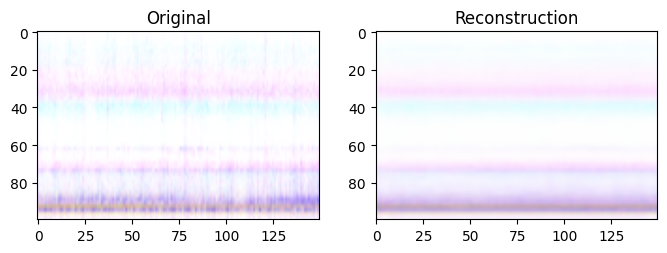

In [64]:
# -----------------------------
# Sample selection
# -----------------------------
idx = 32  # choose any index in the validation set
sample = x_val[idx]

sample_tensor = (
    torch.tensor(sample, dtype=torch.float32)
    .unsqueeze(0)
    .to(device)
)

model.eval()

with torch.no_grad():
    recon = model(sample_tensor)

recon = recon.squeeze(0).cpu().numpy()


sample_plot = np.transpose(sample, (1, 2, 0))
recon_plot = np.transpose(recon, (1, 2, 0))

# -----------------------------
# Reconstruction Error (MSE)
# -----------------------------
mse = np.mean((sample - recon) ** 2)
print(f"Reconstruction MSE: {mse:.6f}")

# -----------------------------
# Visualization: original vs reconstruction
# -----------------------------

mse = np.mean((sample_plot - recon_plot) ** 2)

fig, axs = plt.subplots(1, 2, figsize=(8, 4))

axs[0].imshow(sample_plot)
axs[0].set_title("Original")

axs[1].imshow(recon_plot)
axs[1].set_title("Reconstruction")

plt.show()


## Saving the Trained Model

To enable reuse and reproducibility, we save the trained autoencoder to disk.  
The saved model can later be loaded for evaluation on anomalous data or for inference in other scripts.

In [65]:
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Save the trained model
# -----------------------------

torch.save(
    model.state_dict(),
    MODEL_DIR / "ae_turning_bn16_20260711.pth"
)